<a href="https://colab.research.google.com/github/BhaskarKumarSinha/Ml-Deep-Learning-AI-Projects/blob/main/GENAIProjects/Intelligent_Document_Automation_Building_a_Smart_OCR_Bot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A Comprehension of Intelligent Document Processing

Intelligent Document Processing (IDP) is an advanced automation technology that transforms the way businesses handle documents. By leveraging artificial intelligence (AI), IDP systems can automatically read, understand, and process vast quantities of documents, extracting crucial data and feeding it into various business workflows. This technology is a significant leap from traditional Optical Character Recognition (OCR) as it not only digitizes text but also comprehends the context and structure of the information within documents.

At its core, IDP is designed to tackle the challenge of processing unstructured and semi-structured data, which make up a large portion of business documents such as invoices, contracts, emails, and forms. By automating the extraction and interpretation of this data, IDP significantly reduces the need for manual data entry, leading to increased efficiency, higher accuracy, and substantial cost savings.

<br><br>

---
<br><br>

### The Inner Workings of Intelligent Document Processing

The power of IDP lies in its sophisticated multi-step process that intelligently handles documents from ingestion to data delivery. This process typically involves several key stages:

**1. Document Ingestion:** The first step involves importing documents from various sources and in multiple formats, including scanned paper documents, PDFs, Word files, and images.

**2. Pre-processing:** To enhance the quality of the input, documents undergo a pre-processing stage. This includes techniques like noise reduction, image enhancement, and deskewing to improve the accuracy of subsequent data extraction.

**3. Document Classification:** Using machine learning algorithms, the IDP system automatically categorizes documents based on their layout and content. This allows the system to differentiate between an invoice, a purchase order, or a legal contract, for instance.

**4. Data Extraction:** This is the core function of IDP. Advanced AI technologies, including Natural Language Processing (NLP) and computer vision, are employed to identify and extract relevant data fields. For example, from an invoice, it can pull out the invoice number, date, vendor name, and line-item details.

**5. Data Validation:** The extracted data is then validated against predefined rules and existing databases to ensure accuracy and consistency. Any exceptions or discrepancies can be flagged for human review in a "human-in-the-loop" process, which also helps to train and improve the AI model over time.

**6. Integration:** Finally, the structured and validated data is seamlessly integrated into downstream business systems such as Enterprise Resource Planning (ERP), Customer Relationship Management (CRM), or other databases, making the information readily available for further processing and analysis.


From **finance departments** automating invoice processing and expense management to **healthcare organizations** streamlining patient record management and claims processing, IDP is proving to be a game-changer. Even  **human resources** can expedite resume screening and employee onboarding. As the technology continues to evolve, its applications are expected to expand even further, solidifying its role as a cornerstone of modern digital transformation.

###Datasets

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'resume-dataset' dataset.
Path to dataset files: /kaggle/input/resume-dataset


##Lets play for one image

In [2]:
import os
one_image_path = os.path.join(path, 'data', 'data', 'ENGINEERING','10030015.pdf')

In [3]:
!pip install pdf2image


In [4]:
!apt-get install -y poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.10 [186 kB]
Fetched 186 kB in 2s (121 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 126441 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.10_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.10) ...
Setting up poppler-utils (22.02.0-2ubuntu0.10) ...
Processing triggers for man-db (2.10.2-1) ...


In [7]:
from pdf2image import convert_from_path

pdf_path = os.path.join(path, 'data','data', 'ENGINEERING','10030015.pdf')


# Convert first page of PDF to image
pages = convert_from_path(pdf_path, dpi=300)
one_image = np.array(pages[0])  # Convert PIL Image to numpy array

In [6]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def display_image(image, title="Image"):
    plt.figure(figsize=(7, 7))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

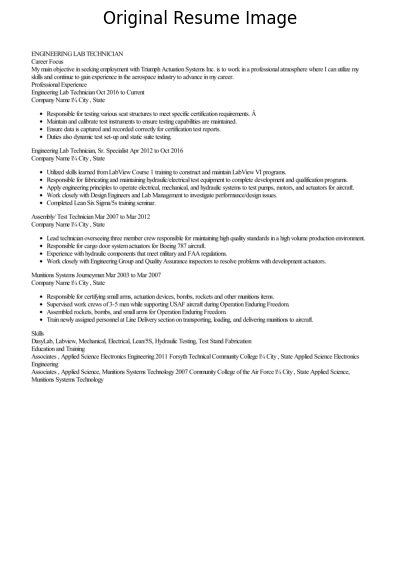

In [ ]:
display_image(one_image, "Original Resume Image")

### Grayscale Conversion

**Why?** Color information is usually not necessary for reading the text on a receipt. Converting the image to grayscale simplifies it from three color channels (Red, Green, Blue) to a single channel (intensity/brightness). This reduces computational complexity and is a required first step for many subsequent operations like thresholding.

In [8]:
# Convert the image to grayscale
def convert_to_grayscale(image):
  return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

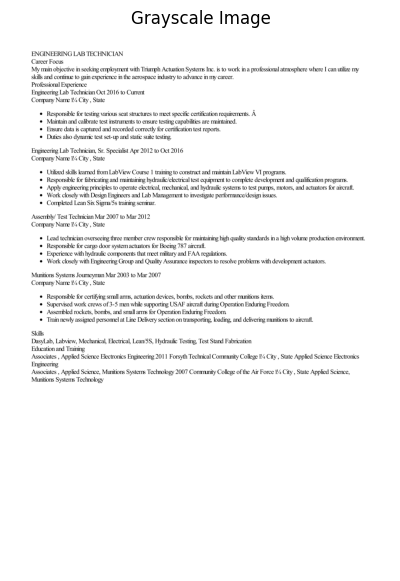

In [9]:
grayscale_image = convert_to_grayscale(one_image)
display_image(grayscale_image, "Grayscale Image")

### Noise (blur) Reduction
**Why?** Scanned images or photos often contain "noise" (random variations in brightness or color). This can look like small specks or graininess, which can confuse OCR algorithms. Applying a slight blur helps to smooth out this noise. A **Gaussian blur** is a common choice as it effectively averages out pixel values with a weighted average, preserving edges better than a simple blur.

In [10]:
def reduce_noise(gray_image):
  return cv2.GaussianBlur(gray_image, (5, 5), 0)

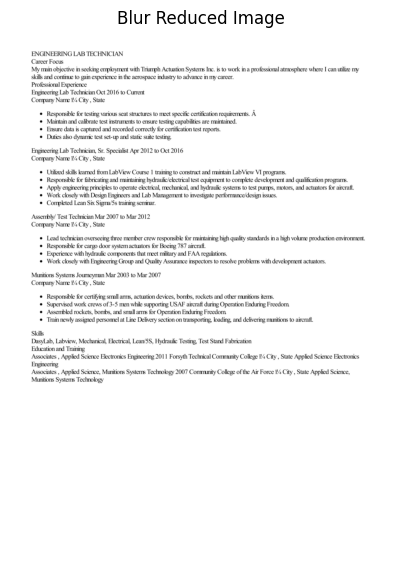

In [11]:
blur_reduced_image = reduce_noise(grayscale_image)
display_image(blur_reduced_image, "Blur Reduced Image")

### Binarization (Thresholding)

**Why?** This is one of the most critical steps. Binarization converts the grayscale image into a pure black-and-white image. The goal is to make the text **black** and the background **white**. However, receipts often have uneven lighting or shadows, so a simple (global) threshold won't work well. We use **adaptive thresholding**, which calculates a different threshold for smaller regions of the image, making it robust to lighting changes.

`cv2.adaptiveThreshold()`:

  * `cv2.ADAPTIVE_THRESH_GAUSSIAN_C`: Calculates the threshold for a pixel based on a weighted sum of neighborhood values.
  * `cv2.THRESH_BINARY_INV`: Inverts the result. We want the text to be white pixels (value 255) and the background black (value 0) for the next step (skew correction), which often works by finding white pixel contours.
  * `11`: The size of the neighborhood area (block size).
  * `4`: A constant subtracted from the mean. It's a fine-tuning parameter.

In [12]:
def binarize_image(blur_reduced_image):
  return cv2.adaptiveThreshold(
    blur_reduced_image,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, # Invert the colors (text becomes white)
    11, # Block size
    4  # Constant C
  )

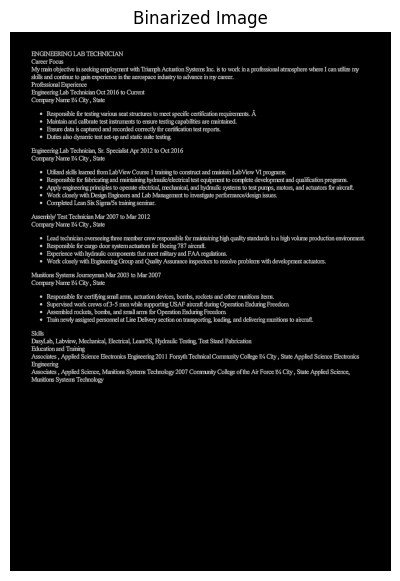

In [13]:
binarized_image = binarize_image(blur_reduced_image)
display_image(binarized_image, "Binarized Image")

### Skew Correction

**Why?** Receipts are often scanned or photographed at a slight angle. This skew can significantly reduce the accuracy of OCR. We need to detect this angle and rotate the image to make the text perfectly horizontal.

A common technique is to find the angle of the minimum-area bounding box that encloses all the text (the white pixels in our binarized image) and then rotate the original image by that angle.

In [20]:
def deskew_image(image):
    """
    Corrects the skew of an image by finding the minimum area rectangle
    of the text block and rotating accordingly.
    """
    # Find all non-zero (white) pixels
    coords = cv2.findNonZero(image)

    # If no non-zero pixels are found, return the original image
    if coords is None:
        print("No non-zero pixels found. Returning original image.")
        return image

    # Get the minimum area bounding rectangle
    # It returns (center(x,y), (width, height), angle of rotation)
    rect = cv2.minAreaRect(coords)
    angle = rect[-1] - 90

    # The `cv2.minAreaRect` angle has a specific range.
    # We need to adjust it for our rotation.
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = angle

    # Get the rotation matrix and rotate the image
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h),
                             flags=cv2.INTER_CUBIC,
                             borderMode=cv2.BORDER_REPLICATE)
    print(f"Detected skew angle: {angle:.2f} degrees")

    # Now, rotate the original grayscale image by the same angle
    (h, w) = rotated.shape
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    deskewed_gray = cv2.warpAffine(rotated, M, (w, h),
                                  flags=cv2.INTER_CUBIC,
                                  borderMode=cv2.BORDER_REPLICATE)

    return deskewed_gray

In [15]:
deskewed_image = deskew_image(binarized_image)

Detected skew angle: 0.00 degrees


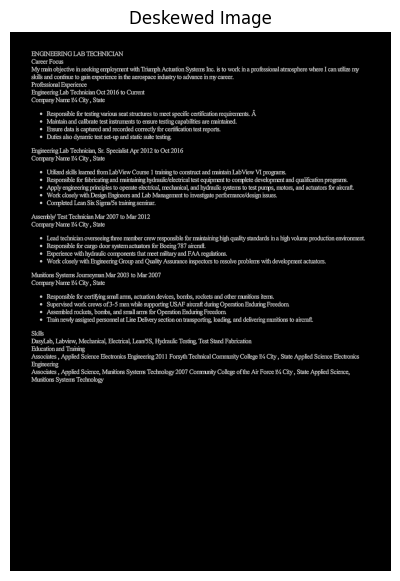

In [16]:
display_image(deskewed_image, "Deskewed Image")

###Let's run the above code for all images


In [17]:
def process_one_image(image):
  image = convert_to_grayscale(image)
  print("Converted image to grayscale..")
  image = reduce_noise(image)
  print("Reduced noise in the image..")
  image = binarize_image(image)
  print("Binarized the image..")
  image = deskew_image(image)
  print("Corrected image orientation..")
  return image

pdf_path = os.path.join(path, 'data','data', 'ENGINEERING','10030015.pdf')

# 🖼️ Image Processing Script

This script processes images from a given folder (`/content/pdf_images`) and saves the processed output in another folder (`/content/processed_images`).  
It also prints logs for each processed image and reports total execution time.

## Text Extraction: Tesseract

In [23]:
! pip install pytesseract pillow


In [24]:
prompt = """
Extract the information from the given resume image.
Information to be extracted: name, email, phone, address, education, skills.
The image has been converted to grayscale, noise reduced, binarized, and deskewed using OpenCV.
Always give your response in the following format:
{
    "name": "FULL_NAME",
    "email": "EMAIL_ADDRESS",
    "phone": "PHONE_NUMBER",
    "address": "ADDRESS",
    "education": "EDUCATION_DETAILS",
    "skills": "LIST_OF_SKILLS"
}
Also, the text has been extracted from the image using Tesseract.
Use the extracted text as support for extracting information.
If you believe the extraction is incorrect somewhere, you may correct it yourself and provide corrected information.
Respond with the extracted information only in the specified format.
Here is the text:
"""


In [25]:
from google import genai
from google.colab import userdata # colab only code
from PIL import Image
import json
import time

In [26]:
genai_client = genai.Client(api_key=userdata.get('GOOGLE_API_KEY'))

## 📄 Convert PDFs to Images using `pdf2image` and `cv2`

This script converts all PDF files in the **ENGINEERING** folder into high-resolution PNG images.  
Each PDF gets its own subfolder inside `/content/pdf_images`, and every page is saved as a separate image.  

### 🔧 Steps:
1. Set the input and output paths.
2. Loop through all files in the source folder.
3. Check for `.pdf` extensions.
4. Convert each PDF into images (300 dpi for clarity).
5. Save images page-by-page into subfolders.

In [18]:
import os
from pdf2image import convert_from_path
import numpy as np
import cv2

# Paths
pdf_path_eng = os.path.join(path, 'data', 'data', 'ENGINEERING')
pdf_output_folder = "/content/pdf_images"  # parent folder
os.makedirs(pdf_output_folder, exist_ok=True)
print(f"PDF images parent folder created: {pdf_output_folder}")

# Supported PDF extension
pdf_extensions = ('.pdf',)

# Convert all PDFs to images
for file_name in os.listdir(pdf_path_eng):
    if file_name.lower().endswith(pdf_extensions):
        file_path = os.path.join(pdf_path_eng, file_name)
        base_name = os.path.splitext(file_name)[0]   # e.g. "resume1"

        # Create subfolder for this PDF
        pdf_subfolder = os.path.join(pdf_output_folder, base_name)
        os.makedirs(pdf_subfolder, exist_ok=True)
        print(f"\nConverting PDF: {file_name}")
        print(f"Saving pages into: {pdf_subfolder}")

        # Convert PDF to images
        pages = convert_from_path(file_path, dpi=300)
        for i, page in enumerate(pages):
            image = np.array(page)
            output_image_name = f"{base_name}_page_{i+1}.png"
            output_path = os.path.join(pdf_subfolder, output_image_name)

            cv2.imwrite(output_path, image)
            print(f"Saved: {output_path}")
    else:
        print(f"Skipped non-PDF file: {file_name}")

print("\n✅ All PDFs converted to images successfully.")


PDF images parent folder created: /content/pdf_images

Converting PDF: 19124258.pdf
Saving pages into: /content/pdf_images/19124258
Saved: /content/pdf_images/19124258/19124258_page_1.png
Saved: /content/pdf_images/19124258/19124258_page_2.png

Converting PDF: 14206561.pdf
Saving pages into: /content/pdf_images/14206561
Saved: /content/pdf_images/14206561/14206561_page_1.png

Converting PDF: 11890896.pdf
Saving pages into: /content/pdf_images/11890896
Saved: /content/pdf_images/11890896/11890896_page_1.png
Saved: /content/pdf_images/11890896/11890896_page_2.png

Converting PDF: 21629057.pdf
Saving pages into: /content/pdf_images/21629057
Saved: /content/pdf_images/21629057/21629057_page_1.png
Saved: /content/pdf_images/21629057/21629057_page_2.png

Converting PDF: 28320387.pdf
Saving pages into: /content/pdf_images/28320387
Saved: /content/pdf_images/28320387/28320387_page_1.png
Saved: /content/pdf_images/28320387/28320387_page_2.png

Converting PDF: 26456899.pdf
Saving pages into: /co

## 🖼️ Batch Processing PDF Images  

This script processes all images generated from PDFs (stored in `/content/pdf_images`) and saves the processed results into `/content/processed_images`.  
Each subfolder from the input is preserved in the output for organized storage.  

### 🔧 Steps:
1. Create a parent folder `processed_images` to store results.  
2. Loop through each resume subfolder inside `pdf_images`.  
3. For each image:
   - Read with OpenCV.  
   - Process it using a custom `process_one_image()` function.  
   - Save the processed image to the corresponding subfolder in `processed_images`.  
4. Track and print total execution time.

In [21]:
import os
import time
import cv2

output_folder_path = "/content/processed_images"
start_time = time.time()

# Create parent output folder
os.makedirs(output_folder_path, exist_ok=True)
print(f"Created parent folder: {output_folder_path}")

input_folder = "/content/pdf_images"

# Loop through each resume folder inside pdf_images
for resume_folder in os.listdir(input_folder):
    resume_path = os.path.join(input_folder, resume_folder)

    # Only process directories (ignore stray files)
    if os.path.isdir(resume_path):
        print(f"\n🔹 Processing resume folder: {resume_folder}")

        # Create matching folder inside processed_images
        processed_resume_folder = os.path.join(output_folder_path, resume_folder)
        os.makedirs(processed_resume_folder, exist_ok=True)

        # Loop through images inside this resume folder
        for image_name in os.listdir(resume_path):
            image_path = os.path.join(resume_path, image_name)
            print(f"Processing image: {image_name}")

            # Read and process image
            image = cv2.imread(image_path)
            processed_image = process_one_image(image)

            # Save processed image into the corresponding output folder
            output_path = os.path.join(processed_resume_folder, image_name)
            cv2.imwrite(output_path, processed_image)
            print(f"Saved processed image to: {output_path}")
            print("-" * 50)

print("\n✅ Processing images completed.")
print(f"⏱️ Total time taken: {time.time() - start_time:.2f} seconds")


Created parent folder: /content/processed_images

🔹 Processing resume folder: 56691064
Processing image: 56691064_page_1.png
Converted image to grayscale..
Reduced noise in the image..
Binarized the image..
Detected skew angle: 0.00 degrees
Corrected image orientation..
Saved processed image to: /content/processed_images/56691064/56691064_page_1.png
--------------------------------------------------
Processing image: 56691064_page_2.png
Converted image to grayscale..
Reduced noise in the image..
Binarized the image..
Detected skew angle: -1.37 degrees
Corrected image orientation..
Saved processed image to: /content/processed_images/56691064/56691064_page_2.png
--------------------------------------------------

🔹 Processing resume folder: 60004873
Processing image: 60004873_page_1.png
Converted image to grayscale..
Reduced noise in the image..
Binarized the image..
Detected skew angle: -0.00 degrees
Corrected image orientation..
Saved processed image to: /content/processed_images/60004

## 📝 OCR Text Extraction from Processed Resume Images

This script extracts text from all processed resume images using **Tesseract OCR** and merges the text into a **single `.txt` file per resume**.  
The folder structure of resumes is preserved, making it easy to track which text belongs to which candidate.

---

### 🔧 Steps:
1. Create a parent folder `tesseract_output` for saving results.  
2. Count total images across all resume subfolders for progress tracking.  
3. Loop through each resume folder in `processed_images`:
   - Read each image in sorted order to maintain page sequence.  
   - Extract text using `pytesseract.image_to_string()`.  
   - Append text to a merged string, with page headers for clarity.  
4. Save the merged text as a single file per resume (`resume_name.txt`).  
5. Print progress and total execution time.

---

In [27]:
import os
from PIL import Image
import pytesseract
import time

input_folder_path = "/content/processed_images"
output_folder_path = "/content/tesseract_output"
start_time = time.time()

# Create parent output folder
os.makedirs(output_folder_path, exist_ok=True)
print(f"Created parent folder: {output_folder_path}")

total_images = 0

# First count all images across all resume subfolders
for resume_folder in os.listdir(input_folder_path):
    resume_path = os.path.join(input_folder_path, resume_folder)
    if os.path.isdir(resume_path):
        total_images += len(os.listdir(resume_path))

print(f"Total images across all resumes: {total_images}")

# Extract text and merge into one file per resume
processed_count = 0
for resume_folder in os.listdir(input_folder_path):
    resume_path = os.path.join(input_folder_path, resume_folder)

    if os.path.isdir(resume_path):
        print(f"\n🔹 Extracting text for resume: {resume_folder}")

        # Create corresponding output subfolder
        output_resume_folder = os.path.join(output_folder_path, resume_folder)
        os.makedirs(output_resume_folder, exist_ok=True)

        # Path for merged output file
        merged_output_path = os.path.join(output_resume_folder, f"{resume_folder}.txt")

        merged_text = ""

        # Loop over images in sorted order (to maintain page sequence)
        for image_name in sorted(os.listdir(resume_path)):
            processed_count += 1
            print(f"Processing image {processed_count}/{total_images}: {image_name}")

            image_path = os.path.join(resume_path, image_name)
            print("Extracting text from image..")

            # OCR extraction
            text = pytesseract.image_to_string(Image.open(image_path))
            merged_text += f"\n\n--- Page: {image_name} ---\n\n{text}"

        # Save merged text once per resume
        with open(merged_output_path, "w") as f:
            f.write(merged_text)

        print(f"✅ Saved merged text file: {merged_output_path}")

print("\n🎉 Text Extraction Completed.")
print(f"⏱️ Total time taken: {time.time() - start_time:.2f} seconds")


Created parent folder: /content/tesseract_output
Total images across all resumes: 227

🔹 Extracting text for resume: 56691064
Processing image 1/227: 56691064_page_1.png
Extracting text from image..
Processing image 2/227: 56691064_page_2.png
Extracting text from image..
✅ Saved merged text file: /content/tesseract_output/56691064/56691064.txt

🔹 Extracting text for resume: 60004873
Processing image 3/227: 60004873_page_1.png
Extracting text from image..
✅ Saved merged text file: /content/tesseract_output/60004873/60004873.txt

🔹 Extracting text for resume: 28630325
Processing image 4/227: 28630325_page_1.png
Extracting text from image..
✅ Saved merged text file: /content/tesseract_output/28630325/28630325.txt

🔹 Extracting text for resume: 31677347
Processing image 5/227: 31677347_page_1.png
Extracting text from image..
Processing image 6/227: 31677347_page_2.png
Extracting text from image..
✅ Saved merged text file: /content/tesseract_output/31677347/31677347.txt

🔹 Extracting text f

## 📄 Extract Structured JSON Data from Resume Texts

This script reads merged OCR text files from processed resume images and uses a **language model** (e.g., Gemini) to extract **structured information** such as name, email, phone, education, skills, and experience.  
The extracted data is saved as **one JSON file per resume**, preserving the folder structure.

---

### 🔧 Steps:
1. Create a parent folder `json_output` for saving results.  
2. Count total resumes to process.  
3. Loop through each resume folder in `tesseract_output`:
   - Read the merged text file (`resume_name.txt`).  
   - Build a prompt including the text (and optionally the first page image).  
   - Send the prompt to the LLM to generate structured JSON content.  
   - Parse and save the JSON to `json_output/{resume_name}/{resume_name}.json`.  
4. Print token usage and progress.  
5. Track total execution time.

---

In [29]:
import os
import time
import json
from PIL import Image

# Paths
image_folder_path = "/content/processed_images"
text_folder_path = "/content/tesseract_output"
output_folder_path = "/content/json_output"

start_time = time.time()

# Create parent output folder
os.makedirs(output_folder_path, exist_ok=True)
print(f"Created parent folder: {output_folder_path}")

# Count total resumes
total_resumes = sum(1 for entry in os.scandir(text_folder_path) if entry.is_dir())
print(f"Total resumes to process: {total_resumes}")

# Process each resume folder
for idx, resume_folder in enumerate(os.listdir(text_folder_path), 1):
    resume_text_path = os.path.join(text_folder_path, resume_folder, f"{resume_folder}.txt")

    if not os.path.isfile(resume_text_path):
        print(f"⚠️ Skipped {resume_folder} (no merged text file found)")
        continue

    print(f"\n🔹 Processing resume {idx}/{total_resumes}: {resume_folder}")

    # Read merged text file
    with open(resume_text_path, "r") as f:
        text = f.read()

    print("Extracting structured information from text...")

    # Build prompt
    prompt += text

    # You may also attach the first page image if needed
    first_image_path = sorted(os.listdir(os.path.join(image_folder_path, resume_folder)))[0]
    image_path = os.path.join(image_folder_path, resume_folder, first_image_path)
    image = Image.open(image_path)

    contents = [
        image,
        {"text": prompt}
    ]

    # Call Gemini (adjust client call as per your setup)
    response = genai_client.models.generate_content(
        model="gemini-2.5-flash",
        contents=contents
    )

    # Usage metadata
    usage_metadata = response.usage_metadata
    print(f"Input Token Count: {usage_metadata.prompt_token_count}")
    print(f"Output Token Count: {usage_metadata.candidates_token_count}")
    print(f"Total Token Count: {usage_metadata.total_token_count}")

    # Parse JSON safely
    extracted_information = json.loads(
        response.text.replace("```json", "").replace("```", "")
    )

    # Save one JSON per resume
    output_resume_folder = os.path.join(output_folder_path, resume_folder)
    os.makedirs(output_resume_folder, exist_ok=True)
    output_path = os.path.join(output_resume_folder, f"{resume_folder}.json")

    with open(output_path, "w") as f:
        json.dump(extracted_information, f, indent=4)

    print(f"✅ Saved extracted information to {output_path}")
    print("-" * 50)

    # Optional: sleep to respect API rate limits
    time.sleep(60)

print("\n🎉 Information Extraction Completed.")
print(f"⏱️ Total time taken: {time.time() - start_time:.2f} seconds")


Created parent folder: /content/json_output
Total resumes to process: 118

🔹 Processing resume 1/118: 56691064
Extracting structured information from text...
Input Token Count: 3081
Output Token Count: 732
Total Token Count: 5105
✅ Saved extracted information to /content/json_output/56691064/56691064.json
--------------------------------------------------

🔹 Processing resume 2/118: 60004873
Extracting structured information from text...
Input Token Count: 3727
Output Token Count: 195
Total Token Count: 4478
✅ Saved extracted information to /content/json_output/60004873/60004873.json
--------------------------------------------------

🔹 Processing resume 3/118: 28630325
Extracting structured information from text...
Input Token Count: 4323
Output Token Count: 270
Total Token Count: 5487
✅ Saved extracted information to /content/json_output/28630325/28630325.json
--------------------------------------------------

🔹 Processing resume 4/118: 31677347
Extracting structured information fro

KeyboardInterrupt: 

## 🔍 Preview Extracted JSON Data from Resumes

This script loads and prints **structured JSON** extracted from resumes.  
It previews the first few resumes for verification purposes.

---

### 🔧 Steps:
1. Set the path to the JSON output folder (`/content/json_output`).  
2. Loop through resume folders.  
3. Open the JSON file for each resume and pretty-print it.  
4. Limit preview to the first 3 resumes to avoid too much output.  


In [30]:
import os
import json

json_output_path = "/content/json_output"

# Loop through a few resume folders
for idx, resume_folder in enumerate(os.listdir(json_output_path)):
    resume_path = os.path.join(json_output_path, resume_folder, f"{resume_folder}.json")

    if os.path.isfile(resume_path):
        print(f"\n📂 Resume: {resume_folder}")
        with open(resume_path, "r") as f:
            data = json.load(f)

        # Pretty-print JSON
        print(json.dumps(data, indent=4))

    if idx >= 2:  # limit to first 3 resumes
        break



📂 Resume: 56691064
{
    "name": null,
    "email": null,
    "phone": null,
    "address": "Glendale, CA (implied by colleges and municipal code)",
    "education": [
        "Bachelor of Science: Geography Social Sciences, June 2012, California Polytechnic State University Pomona (GIS GPA: Pi Gamma Mu Geography Pi Gamma Mu Social Sciences)",
        "Associates Degree: Architecture, June 2009, Glendale Community College Architecture",
        "Civil Design Technology, December 2012, Rio Hondo Community College Civil Design Technology",
        "GCC Certificate, Architectural CAD",
        "GCC Certificate, Architectural Drafting (GPA: President and Vice President of the American Society of Engineers and Architects Club (ASEA) Dean's list, President and Vice President of the American Society of Engineers and Architects Club (ASEA) Dean's list)"
    ],
    "skills": [
        "Operating Systems: Windows XP/Vista/7",
        "GIS Software: ArcGIS (9.3.1, 10.0), ArcFM (9.3.1/10.0.3), ER